<a href="https://colab.research.google.com/github/Sarumathi-G23/Clustering-Algorithm/blob/main/Air_Quality_Pattern_Discovery_Using_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [3]:
df = pd.read_csv("/content/AirQuality.csv", sep=';', engine='python')



In [5]:
df = df.dropna(axis=1, how='all')#removing empty col


In [6]:
df = df.drop(columns=['Date', 'Time'], errors='ignore')



In [8]:
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
        except ValueError:
            # If conversion fails for a column, it's genuinely non-numeric, so keep it as is or handle differently
            pass
df.replace(-200, np.nan, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


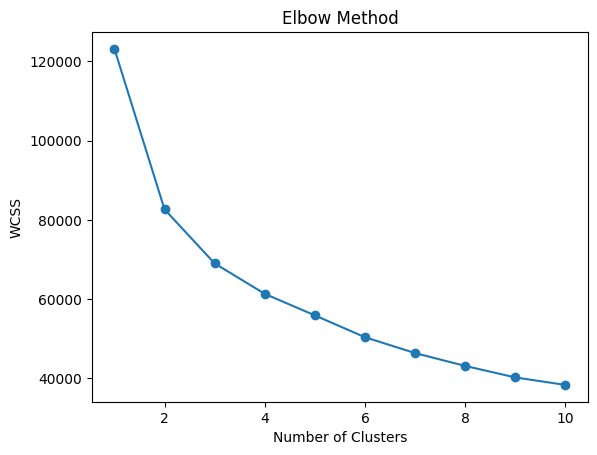

In [10]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters


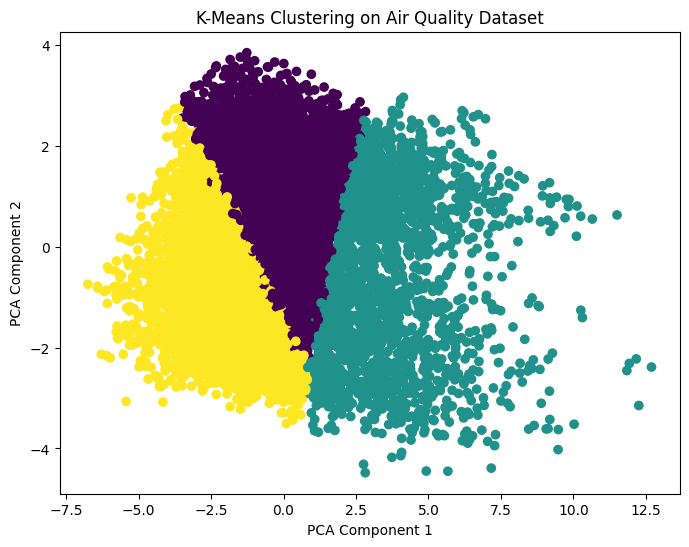

In [12]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering on Air Quality Dataset")
plt.show()


In [13]:
print(df['Cluster'].value_counts())


Cluster
0    4049
2    3292
1    2130
Name: count, dtype: int64
